In [ ]:
!pip install -q pycocotools tqdm

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil
from pathlib import Path

from tqdm import tqdm
from pycocotools.coco import COCO

In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

FLIR_ROOT = os.path.join(PROJECT_ROOT, "datasets", "flir")

TRAIN_DIR = os.path.join(FLIR_ROOT, "images_thermal_train")
VAL_DIR = os.path.join(FLIR_ROOT, "images_thermal_val")

TRAIN_JSON = os.path.join(TRAIN_DIR, "coco.json")
VAL_JSON = os.path.join(VAL_DIR, "coco.json")

OUTPUT_DIR = os.path.join(FLIR_ROOT, "flir_yolo")

In [ ]:
for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    Path(os.path.join(OUTPUT_DIR, folder)).mkdir(parents=True, exist_ok=True)

print("Dataset folders created.")

Dataset folders created.


In [ ]:
def convert_split(image_dir, coco_json, output_image_dir, output_label_dir):
    """
    Convert a FLIR COCO dataset split to YOLO format.

    Args:
        image_dir (str): Path to the FLIR split directory.
        coco_json (str): Path to the COCO annotation file.
        output_image_dir (str): Output directory for YOLO images.
        output_label_dir (str): Output directory for YOLO labels.

    Returns:
        tuple: (number_of_images_copied, number_of_person_boxes)
    """

    coco = COCO(coco_json)

    # Find person category ID
    person_id = None
    for cat in coco.loadCats(coco.getCatIds()):
        if cat["name"].lower() == "person":
            person_id = cat["id"]
            break

    if person_id is None:
        raise ValueError("Person category not found in COCO annotations.")

    image_ids = coco.getImgIds()

    copied_images = 0
    total_boxes = 0
    missing_images = 0

    for image_id in tqdm(image_ids):

        image_info = coco.loadImgs(image_id)[0]

        filename = image_info["file_name"]      # e.g. data/video-xxxx.jpg
        width = image_info["width"]
        height = image_info["height"]

        # Source image path
        src = os.path.join(image_dir, filename)

        # Destination image path
        image_name = os.path.basename(filename)
        dst = os.path.join(output_image_dir, image_name)

        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied_images += 1
        else:
            missing_images += 1
            print(f"Missing image: {src}")
            continue

        # Load only person annotations
        ann_ids = coco.getAnnIds(
            imgIds=image_id,
            catIds=[person_id],
            iscrowd=None
        )

        anns = coco.loadAnns(ann_ids)

        # YOLO label file
        label_path = os.path.join(
            output_label_dir,
            Path(image_name).stem + ".txt"
        )

        with open(label_path, "w") as f:

            for ann in anns:

                x, y, w, h = ann["bbox"]

                x_center = (x + w / 2) / width
                y_center = (y + h / 2) / height
                box_width = w / width
                box_height = h / height

                f.write(
                    f"0 {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}\n"
                )

                total_boxes += 1

    print(f"\nImages copied : {copied_images}")
    print(f"Missing images: {missing_images}")
    print(f"Person boxes  : {total_boxes}")

    return copied_images, total_boxes

In [ ]:
train_images, train_labels = convert_split(
    TRAIN_DIR,
    TRAIN_JSON,
    os.path.join(OUTPUT_DIR, "images/train"),
    os.path.join(OUTPUT_DIR, "labels/train"),
)

print(train_images, train_labels)

loading annotations into memory...
Done (t=0.78s)
creating index...
index created!


100%|██████████| 10742/10742 [1:00:01<00:00,  2.98it/s]


Images copied : 10742
Missing images: 0
Person boxes  : 50478
10742 50478


In [ ]:
val_images, val_labels = convert_split(
    VAL_DIR,
    VAL_JSON,
    os.path.join(OUTPUT_DIR, "images/val"),
    os.path.join(OUTPUT_DIR, "labels/val"),
)

print(val_images, val_labels)

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


100%|██████████| 1144/1144 [05:42<00:00,  3.34it/s]


Images copied : 1144
Missing images: 0
Person boxes  : 4470
1144 4470


In [ ]:
print("=" * 50)

print("FLIR Thermal Dataset Conversion Complete")

print("=" * 50)

print(f"Training Images     : {train_images}")
print(f"Validation Images   : {val_images}")

print(f"Training Boxes      : {train_labels}")
print(f"Validation Boxes    : {val_labels}")

print(f"Total Images        : {train_images + val_images}")
print(f"Total Person Boxes  : {train_labels + val_labels}")

FLIR Thermal Dataset Conversion Complete
Training Images     : 10742
Validation Images   : 1144
Training Boxes      : 50478
Validation Boxes    : 4470
Total Images        : 11886
Total Person Boxes  : 54948


In [ ]:
import os
import random
import yaml

import cv2
import matplotlib.pyplot as plt

In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

YOLO_ROOT = os.path.join(PROJECT_ROOT, "datasets", "flir", "flir_yolo")

TRAIN_IMAGES = os.path.join(YOLO_ROOT, "images", "train")
VAL_IMAGES = os.path.join(YOLO_ROOT, "images", "val")

TRAIN_LABELS = os.path.join(YOLO_ROOT, "labels", "train")
VAL_LABELS = os.path.join(YOLO_ROOT, "labels", "val")

In [ ]:
data = {
    "path": YOLO_ROOT,
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "person"
    }
}

yaml_path = os.path.join(YOLO_ROOT, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Created:", yaml_path)

Created: /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/data.yaml


In [ ]:
train_images = len(os.listdir(TRAIN_IMAGES))
train_labels = len(os.listdir(TRAIN_LABELS))

val_images = len(os.listdir(VAL_IMAGES))
val_labels = len(os.listdir(VAL_LABELS))

print("="*50)
print("Dataset Summary")
print("="*50)

print(f"Train Images : {train_images}")
print(f"Train Labels : {train_labels}")

print(f"Validation Images : {val_images}")
print(f"Validation Labels : {val_labels}")

Dataset Summary
Train Images : 10742
Train Labels : 10742
Validation Images : 1144
Validation Labels : 1144


In [ ]:
def visualize_sample(image_dir, label_dir):

    image_name = random.choice(os.listdir(image_dir))

    image_path = os.path.join(image_dir, image_name)
    label_path = os.path.join(
        label_dir,
        os.path.splitext(image_name)[0] + ".txt"
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    if os.path.exists(label_path):

        with open(label_path) as f:

            for line in f:

                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0,255,0),
                    2
                )

    plt.figure(figsize=(8,6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [ ]:
for _ in range(10):
    visualize_sample(TRAIN_IMAGES, TRAIN_LABELS)

Output hidden; open in https://colab.research.google.com to view.

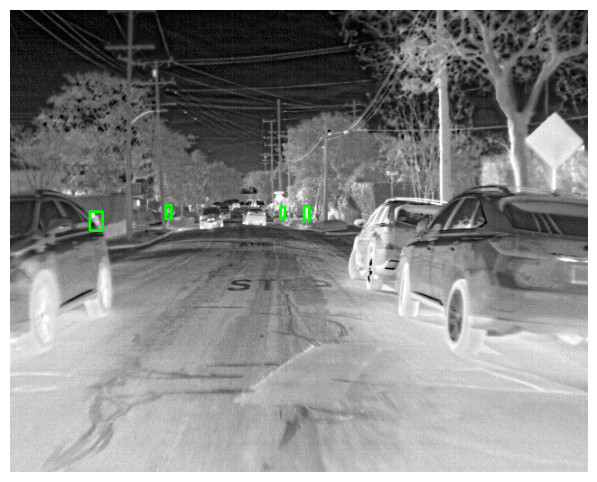

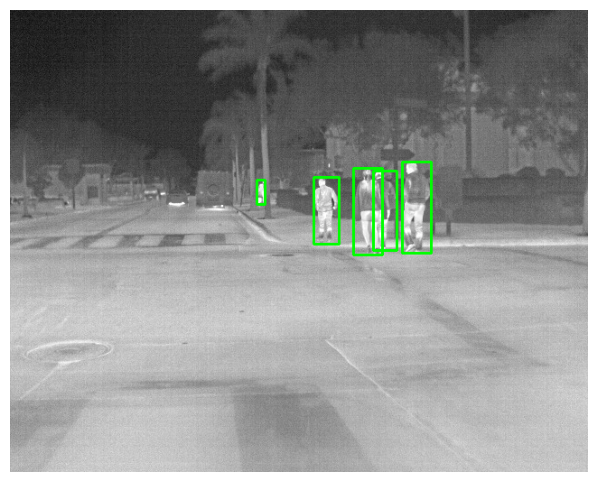

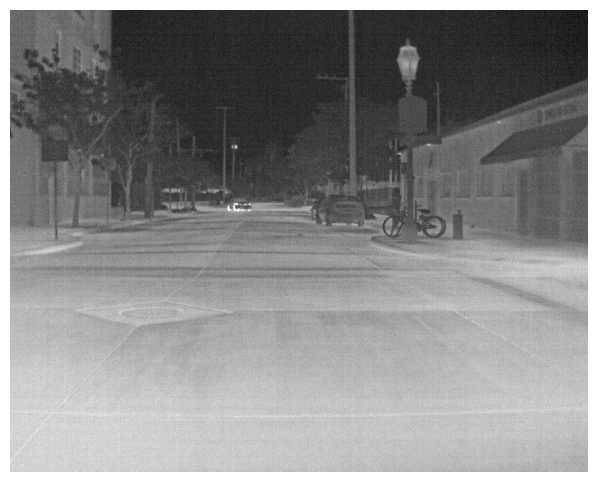

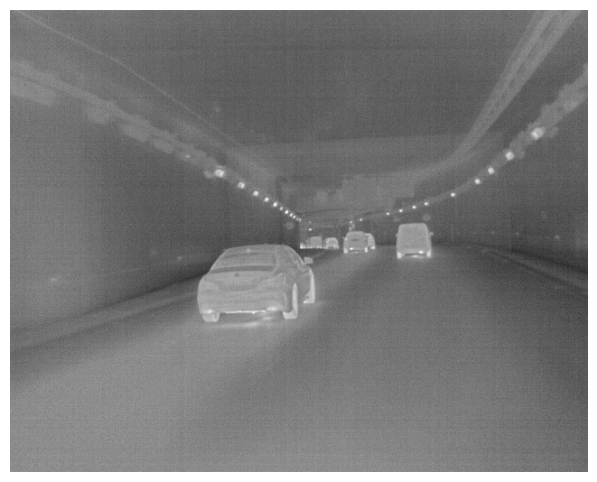

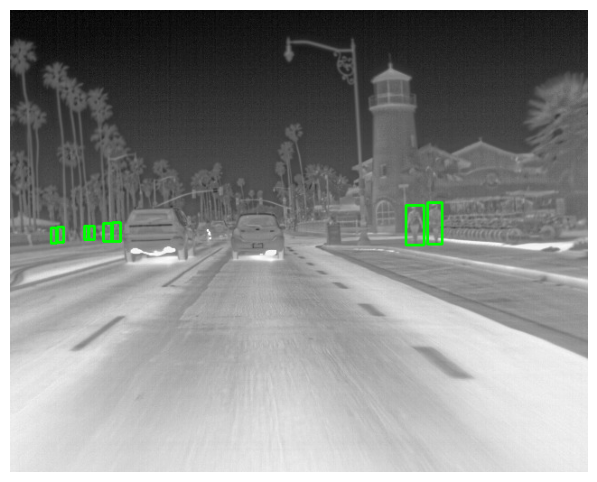

In [ ]:
for _ in range(5):
    visualize_sample(VAL_IMAGES, VAL_LABELS)

In [ ]:
missing = []

for image in os.listdir(TRAIN_IMAGES):

    label = os.path.splitext(image)[0] + ".txt"

    if not os.path.exists(os.path.join(TRAIN_LABELS, label)):
        missing.append(image)

print("Missing labels:", len(missing))

Missing labels: 0


In [ ]:
empty = 0

for label in os.listdir(TRAIN_LABELS):

    path = os.path.join(TRAIN_LABELS, label)

    if os.path.getsize(path) == 0:
        empty += 1

print("Empty label files:", empty)

Empty label files: 2537


In [ ]:
print("="*60)
print("FLIR YOLO DATASET VALIDATION")
print("="*60)

print(f"Training Images     : {train_images}")
print(f"Training Labels     : {train_labels}")

print(f"Validation Images   : {val_images}")
print(f"Validation Labels   : {val_labels}")

print(f"Missing Labels      : {len(missing)}")
print(f"Empty Label Files   : {empty}")

print("\nDataset validation completed successfully.")

FLIR YOLO DATASET VALIDATION
Training Images     : 10742
Training Labels     : 10742
Validation Images   : 1144
Validation Labels   : 1144
Missing Labels      : 0
Empty Label Files   : 2537

Dataset validation completed successfully.
